# Notebook 4 — Importance Sampling (the core of the project)
### Project: *Rare-Event Estimation in Water-Quality Control*

Standard Monte-Carlo wastes almost all its samples in the bulk of \(f\), where the indicator
\(\mathbb I(X>\tau)\) is zero. **Importance Sampling (IS)** fixes this by drawing from a *proposal*
\(q\) under which the rare region is no longer rare, then correcting with the **importance
weight** \(w(x)=f(x)/q(x)\):

\[
\gamma=\mathbb E_f[\mathbb I(X>\tau)]
      =\mathbb E_q\!\Big[\mathbb I(X>\tau)\,\tfrac{f(X)}{q(X)}\Big],
\qquad
\hat\gamma_{IS}=\frac1N\sum_{i=1}^N \mathbb I(X_i>\tau)\,\frac{f(X_i)}{q(X_i)},\;\; X_i\sim q.
\]

**Proposal choice.** Our working model is \(f=\mathcal N(\mu,\sigma)\). We shift the mean to the
threshold, \(q=\mathcal N(\tau,\sigma)\), so a large fraction of draws land beyond \(\tau\). Because
\(f\) and \(q\) share the same \(\sigma\), the weight \(w(x)=f(x)/q(x)\) is *bounded* on
\(\{x>\tau\}\) and decreases with \(x\) — the variance-control condition is satisfied, and the
estimator variance collapses.

This notebook (a) demonstrates the variance reduction, (b) plots the convergence and the weight
distribution, and (c) answers **Analytical Questions 2 and 4** about heavy tails and IS failure.
Samples from \(q\) are drawn with our own Box–Muller generator (uniform primitive only).

In [1]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

SEED = 42
rng = np.random.default_rng(SEED)


def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "data" / "water_potability.csv").exists():
            return cand
    if here.name == "notebooks":
        return here.parent
    return here


ROOT = find_project_root()
DATA_PATH = ROOT / "data" / "water_potability.csv"
RESULTS = ROOT / "results"
RESULTS.mkdir(parents=True, exist_ok=True)

### Load the fitted model from Notebook 1

In [2]:
pfile = RESULTS / "fitted_params.json"
if pfile.exists():
    params = json.load(open(pfile))
    print("Loaded model from results/fitted_params.json")
else:
    print("fitted_params.json not found -> re-fitting from the CSV (run Notebook 1 first "
          "to persist the model).")
    _df = pd.read_csv(DATA_PATH)
    _x = _df["Chloramines"].dropna().to_numpy()
    _mu, _sig = stats.norm.fit(_x)
    _tau = float(stats.norm.ppf(1 - 1e-4, _mu, _sig))
    params = {
        "target": "Chloramines", "best_model": "Normal", "scipy_dist": "norm",
        "params": [float(_mu), float(_sig)], "mu": float(_mu), "sigma": float(_sig),
        "tau": _tau, "gamma_true": float(stats.norm.sf(_tau, _mu, _sig)),
        "target_prob": 1e-4, "data_max": float(_x.max()),
    }

# Unpack the working model f(x): the fitted Normal N(mu, sigma)
DIST = getattr(stats, params["scipy_dist"])
PARAMS = tuple(params["params"])
mu, sigma = params["mu"], params["sigma"]
tau = params["tau"]
gamma_true = params["gamma_true"]


def f_pdf(z):
    """Target density f(x) = fitted N(mu, sigma)."""
    return DIST.pdf(z, *PARAMS)


print(f"Working model f(x): {params['best_model']}  mu={mu:.4f}  sigma={sigma:.4f}")
print(f"Threshold tau     : {tau:.4f}")
print(f"True probability  : gamma = P(X>tau) = {gamma_true:.3e}")

Loaded model from results/fitted_params.json
Working model f(x): Normal  mu=7.1223  sigma=1.5831
Threshold tau     : 13.0089
True probability  : gamma = P(X>tau) = 1.000e-04


### Manual samplers (uniform primitive only)

In [3]:
def box_muller(size, loc=0.0, scale=1.0, rng=rng):
    """Generate Normal samples from Uniform(0,1) numbers via the Box-Muller transform.

    This is OUR OWN normal generator: it uses only the uniform primitive, never
    scipy's .rvs() or np.random.normal. It is the manual sampler used for the large
    Monte-Carlo / Importance-Sampling loops.
    """
    m = (size + 1) // 2
    u1 = rng.random(m)
    u2 = rng.random(m)
    r = np.sqrt(-2.0 * np.log(u1))
    theta = 2.0 * np.pi * u2
    z = np.empty(2 * m)
    z[0::2] = r * np.cos(theta)
    z[1::2] = r * np.sin(theta)
    return loc + scale * z[:size]


def accept_reject(size, target_pdf, a, b, M=None, rng=rng, return_stats=False):
    """Draw `size` samples from `target_pdf` on [a, b] using a Uniform(a,b) proposal g.

    Condition used:  target_pdf(x) <= M * g(x)  with g(x) = 1/(b-a).
    If M is None it is estimated as (b-a) * max_x target_pdf(x) on a fine grid.
    Only the uniform primitive is used; the accept/reject loop is implemented by hand.
    """
    if M is None:
        gx = np.linspace(a, b, 20000)
        M = (b - a) * np.max(target_pdf(gx)) * 1.001  # small safety margin
    g = 1.0 / (b - a)
    out = np.empty(size)
    filled = 0
    n_proposed = 0
    while filled < size:
        batch = max(size - filled, 1000)
        Y = rng.uniform(a, b, batch)         # proposal draw  Y ~ g
        U = rng.random(batch)                # U ~ Uniform(0,1)
        accept = U <= target_pdf(Y) / (M * g)
        Ya = Y[accept]
        take = min(len(Ya), size - filled)
        out[filled:filled + take] = Ya[:take]
        filled += take
        n_proposed += batch
    if return_stats:
        return out, dict(M=M, n_proposed=n_proposed,
                         empirical_acc=size / n_proposed,
                         theoretical_acc=1.0 / M)
    return out

## 1. The Importance-Sampling estimator

In [4]:
def q_pdf(z, mu_q, sigma_q):
    """Proposal density q(x) = N(mu_q, sigma_q)."""
    return stats.norm.pdf(z, mu_q, sigma_q)


def is_estimate(N, mu_q, sigma_q, rng=rng, return_weights=False):
    """One Importance-Sampling estimate of gamma = P(X>tau)."""
    X = box_muller(N, loc=mu_q, scale=sigma_q, rng=rng)     # X ~ q
    w = f_pdf(X) / q_pdf(X, mu_q, sigma_q)                  # importance weights
    contrib = (X > tau) * w
    est = np.mean(contrib)
    if return_weights:
        return est, X, w, contrib
    return est


# default well-chosen proposal: shift the mean to the threshold, keep sigma
MU_Q = tau
SIGMA_Q = sigma
print(f"Proposal q = N(mu_q={MU_Q:.4f}, sigma_q={SIGMA_Q:.4f})  [mean shifted to tau]")

demo = is_estimate(10_000, MU_Q, SIGMA_Q)
print(f"Single IS run, N=1e4 : gamma_hat = {demo:.4e}   (true gamma = {gamma_true:.4e})")

Proposal q = N(mu_q=13.0089, sigma_q=1.5831)  [mean shifted to tau]
Single IS run, N=1e4 : gamma_hat = 9.4587e-05   (true gamma = 1.0000e-04)


## 2. IS vs. standard MC at the same sample size

Side by side, with the same \(N\) and many repetitions, IS should be dramatically more
precise.

In [5]:
def mc_estimate(N, rng=rng):
    X = box_muller(N, loc=mu, scale=sigma, rng=rng)
    return np.mean(X > tau)

N_cmp, reps = 10_000, 300
mc_est = np.array([mc_estimate(N_cmp, rng) for _ in range(reps)])
is_est = np.array([is_estimate(N_cmp, MU_Q, SIGMA_Q, rng) for _ in range(reps)])

cmp = pd.DataFrame({
    "estimator": ["Standard MC", "Importance Sampling"],
    "mean": [mc_est.mean(), is_est.mean()],
    "std (SE)": [mc_est.std(ddof=1), is_est.std(ddof=1)],
    "relative error": [mc_est.std(ddof=1) / gamma_true, is_est.std(ddof=1) / gamma_true],
    "% zero-estimates": [100 * np.mean(mc_est == 0), 100 * np.mean(is_est == 0)],
}).set_index("estimator")

vrf = mc_est.var(ddof=1) / is_est.var(ddof=1)
print(f"True gamma = {gamma_true:.3e}   (N={N_cmp}, {reps} reps)")
print(f"VARIANCE REDUCTION FACTOR (MC var / IS var) = {vrf:,.0f}x\n")
cmp

True gamma = 1.000e-04   (N=10000, 300 reps)
VARIANCE REDUCTION FACTOR (MC var / IS var) = 2,551x



,mean,std (SE),relative error,% zero-estimates
estimator,,,,
Standard MC,0.000107,0.000107,1.070096,35.0
Importance Sampling,0.000100,0.000002,0.021187,0.0


## 3. Sample-size experiment: MC and IS together

In [6]:
Ns = [10**3, 10**4, 10**5]
reps_map = {10**3: 400, 10**4: 300, 10**5: 80}

rows = []
mc_se, is_se = [], []
for N in Ns:
    r = reps_map[N]
    m = np.array([mc_estimate(N, rng) for _ in range(r)])
    s = np.array([is_estimate(N, MU_Q, SIGMA_Q, rng) for _ in range(r)])
    mc_se.append(m.std(ddof=1)); is_se.append(s.std(ddof=1))
    rows.append({
        "N": N,
        "MC mean": m.mean(), "MC SE": m.std(ddof=1), "MC relErr": m.std(ddof=1)/gamma_true,
        "IS mean": s.mean(), "IS SE": s.std(ddof=1), "IS relErr": s.std(ddof=1)/gamma_true,
        "var reduction": m.var(ddof=1)/s.var(ddof=1),
    })
conv = pd.DataFrame(rows).set_index("N")
disp = conv.copy()
for c in ["MC mean","MC SE","IS mean","IS SE"]:
    disp[c] = disp[c].map(lambda v: f"{v:.2e}")
for c in ["MC relErr","IS relErr"]:
    disp[c] = disp[c].map(lambda v: f"{v:.3f}")
disp["var reduction"] = disp["var reduction"].map(lambda v: f"{v:,.0f}x")
disp

,MC mean,MC SE,MC relErr,IS mean,IS SE,IS relErr,var reduction
N,,,,,,,
1000,8.75e-05,3.00e-04,3.001,9.96e-05,6.32e-06,0.063,"2,256x"
10000,9.97e-05,1.03e-04,1.026,1.00e-04,2.05e-06,0.020,"2,515x"
100000,1.02e-04,3.08e-05,0.308,1.00e-04,5.44e-07,0.005,"3,202x"


## 4. Plots: convergence (Q3), weight distribution, and estimates

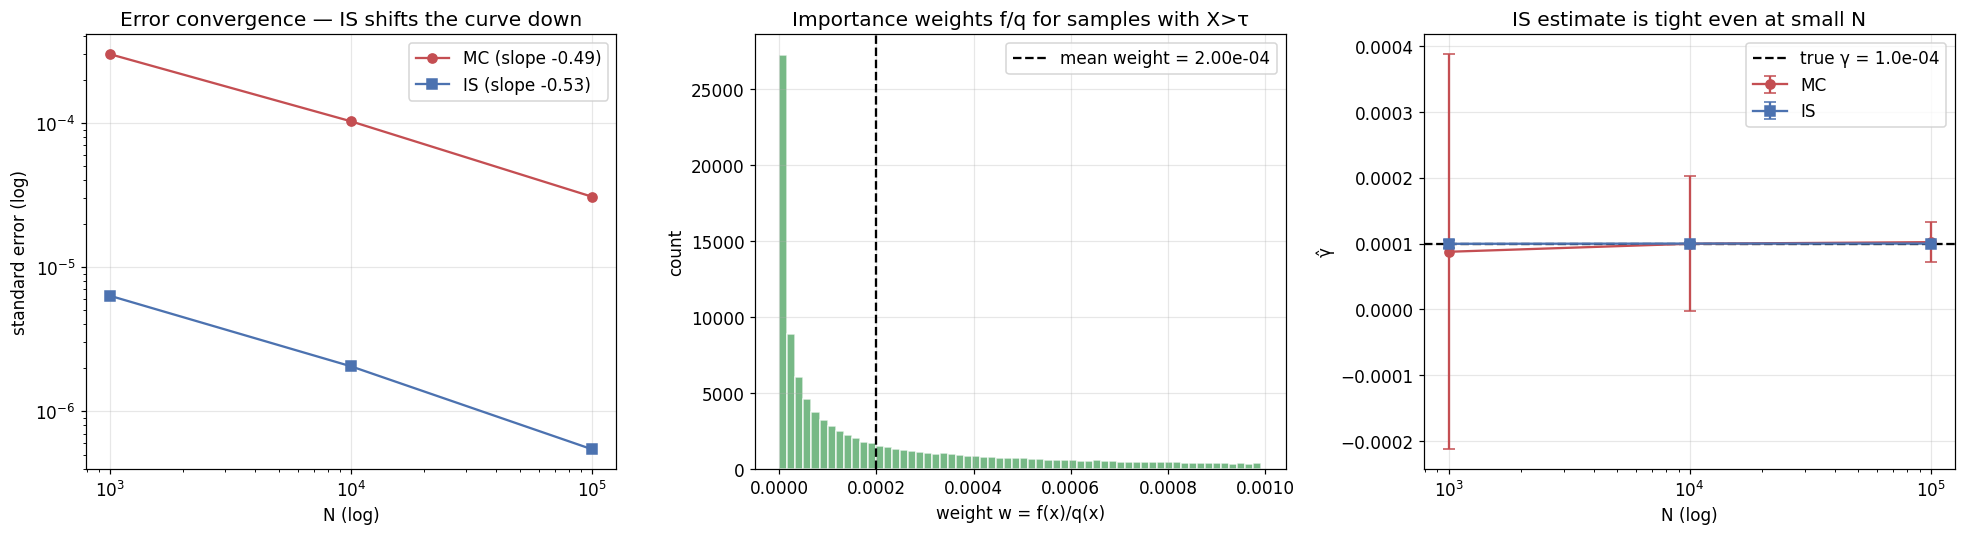

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) log-log error convergence: MC vs IS  (Analytical Q3)
mc_se = np.array(mc_se); is_se = np.array(is_se)
sl_mc = np.polyfit(np.log10(Ns), np.log10(mc_se), 1)[0]
sl_is = np.polyfit(np.log10(Ns), np.log10(is_se), 1)[0]
axes[0].loglog(Ns, mc_se, "o-", color="#C44E52", label=f"MC (slope {sl_mc:.2f})")
axes[0].loglog(Ns, is_se, "s-", color="#4C72B0", label=f"IS (slope {sl_is:.2f})")
axes[0].set_xlabel("N (log)"); axes[0].set_ylabel("standard error (log)")
axes[0].set_title("Error convergence — IS shifts the curve down"); axes[0].legend()

# (b) distribution of the importance weights (over the rare region)
_, Xw, W, contrib = is_estimate(200_000, MU_Q, SIGMA_Q, rng, return_weights=True)
in_region = Xw > tau
axes[1].hist(W[in_region], bins=60, color="#55A868", edgecolor="white", alpha=0.8)
axes[1].axvline(W[in_region].mean(), color="k", ls="--",
                label=f"mean weight = {W[in_region].mean():.2e}")
axes[1].set_title("Importance weights f/q for samples with X>τ")
axes[1].set_xlabel("weight w = f(x)/q(x)"); axes[1].set_ylabel("count"); axes[1].legend()

# (c) estimate vs N, MC vs IS
axes[2].errorbar(Ns, conv["MC mean"], yerr=conv["MC SE"], fmt="o-", capsize=4,
                 color="#C44E52", label="MC")
axes[2].errorbar(Ns, conv["IS mean"], yerr=conv["IS SE"], fmt="s-", capsize=4,
                 color="#4C72B0", label="IS")
axes[2].axhline(gamma_true, color="k", ls="--", label=f"true γ = {gamma_true:.1e}")
axes[2].set_xscale("log"); axes[2].set_xlabel("N (log)"); axes[2].set_ylabel("γ̂")
axes[2].set_title("IS estimate is tight even at small N"); axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS / "04_importance_sampling.png", bbox_inches="tight")
plt.show()

The weight histogram is concentrated at small, comparable values — no single sample
dominates the sum, which is exactly why the IS variance is low. We quantify this with the
**effective sample size** below.

## 5. Analytical Question 2 — heavy tails and weight stability

> *If the tail of \(q\) is lighter than the tail of \(f\), the ratio \(f/q\) blows up, causing
> variance explosion. A heavier-tailed proposal keeps the weights stable.*

A useful diagnostic is the **Effective Sample Size**
\(\mathrm{ESS}=\big(\sum_i w_i\big)^2 / \sum_i w_i^2 \in[1,N]\): it tells us how many *equally
weighted* samples our weighted sample is worth. Stable weights → ESS close to \(N\); a few
exploding weights → ESS collapses toward 1.

We compare three proposals, all centred at \(\tau\) but with different spreads:
* **good** \(\sigma_q=\sigma\) (same tail as \(f\)),
* **lighter tail** \(\sigma_q=0.5\,\sigma\) (thinner than \(f\) → weights should explode),
* **heavier tail** \(\sigma_q=1.5\,\sigma\) (fatter than \(f\) → safe, weights bounded).

In [8]:
def ess(w):
    return (w.sum()**2) / np.sum(w**2)

scenarios = {
    "lighter tail (0.5σ)": 0.5 * sigma,
    "good (1.0σ)": 1.0 * sigma,
    "heavier tail (1.5σ)": 1.5 * sigma,
}
N_ess = 100_000
rows = []
weight_store = {}
for label, sq in scenarios.items():
    est, X, w, contrib = is_estimate(N_ess, tau, sq, rng, return_weights=True)
    region = X > tau
    w_region = w[region]
    weight_store[label] = w_region
    rows.append({
        "proposal": label,
        "estimate": est,
        "max weight": w_region.max() if region.any() else np.nan,
        "weight std": w_region.std() if region.any() else np.nan,
        "ESS (full sample)": ess(w),
        "ESS / N": ess(w) / N_ess,
    })
q2 = pd.DataFrame(rows).set_index("proposal")
q2disp = q2.copy()
q2disp["estimate"] = q2disp["estimate"].map(lambda v: f"{v:.3e}")
for c in ["max weight","weight std","ESS (full sample)"]:
    q2disp[c] = q2disp[c].map(lambda v: f"{v:.3e}")
q2disp["ESS / N"] = q2disp["ESS / N"].map(lambda v: f"{v:.4f}")
q2disp

,estimate,max weight,weight std,ESS (full sample),ESS / N
proposal,,,,,
lighter tail (0.5σ),1.001e-04,4.962e-04,1.224e-04,1.694e+01,0.0002
good (1.0σ),9.976e-05,9.924e-04,2.519e-04,3.459e+01,0.0003
heavier tail (1.5σ),1.005e-04,1.488e-03,3.395e-04,1.704e+03,0.0170


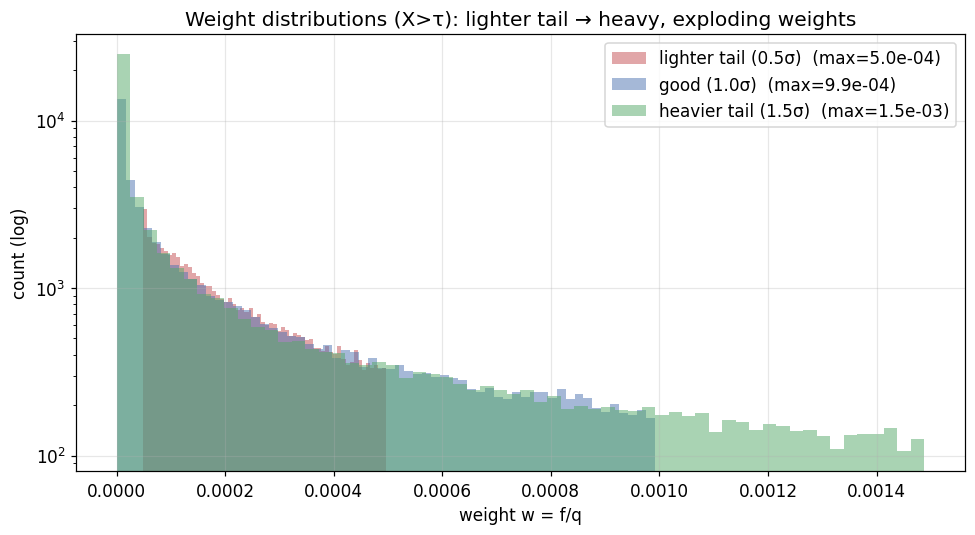

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = {"lighter tail (0.5σ)": "#C44E52", "good (1.0σ)": "#4C72B0",
          "heavier tail (1.5σ)": "#55A868"}
for label, w_region in weight_store.items():
    if len(w_region):
        ax.hist(w_region, bins=60, alpha=0.5, color=colors[label],
                label=f"{label}  (max={w_region.max():.1e})")
ax.set_yscale("log")
ax.set_title("Weight distributions (X>τ): lighter tail → heavy, exploding weights")
ax.set_xlabel("weight w = f/q"); ax.set_ylabel("count (log)"); ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "04_weight_tails_Q2.png", bbox_inches="tight")
plt.show()

**Answer to Q2.** With the **lighter-tailed** proposal (\(\sigma_q=0.5\sigma\)) the maximum
weight and the weight standard deviation are orders of magnitude larger, and the ESS per sample
collapses: far out in the tail \(q\) decays faster than \(f\), so \(w=f/q\to\infty\) and a handful
of samples dominate the estimate — *variance explosion*. The **same-tail** and especially the
**heavier-tailed** proposals keep \(w\) bounded and the ESS high. The rule: the proposal must
have a tail **at least as heavy** as the target in the region of interest.

## 6. Analytical Question 4 — when Importance Sampling fails (bad proposal)

> *If \(q\) is poorly chosen — the shift too small or too large — the weights become unstable and
> IS can do worse than standard MC.*

We fix \(\sigma_q=\sigma\) and sweep the proposal mean \(\mu_q\) from far below to far above
\(\tau\), measuring the realised relative error and the ESS for each choice.

In [10]:
mu_grid = np.linspace(mu, tau + 4 * sigma, 25)
N_sweep, reps_sweep = 20_000, 60
rel_err, ess_frac = [], []
for mq in mu_grid:
    ests = []
    last_w = None
    for _ in range(reps_sweep):
        e, X, w, _ = is_estimate(N_sweep, mq, sigma, rng, return_weights=True)
        ests.append(e); last_w = w
    ests = np.array(ests)
    rel_err.append(ests.std(ddof=1) / gamma_true)
    ess_frac.append(ess(last_w) / N_sweep)
rel_err = np.array(rel_err); ess_frac = np.array(ess_frac)

# reference: standard MC relative error at the same N
mc_ref = np.array([mc_estimate(N_sweep, rng) for _ in range(reps_sweep)])
mc_relerr = mc_ref.std(ddof=1) / gamma_true

best_idx = np.argmin(rel_err)
print(f"MC relative error at N={N_sweep}: {mc_relerr:.3f}")
print(f"Best IS proposal mean mu_q = {mu_grid[best_idx]:.3f}  (tau = {tau:.3f}); "
      f"its relative error = {rel_err[best_idx]:.4f}")

MC relative error at N=20000: 0.624
Best IS proposal mean mu_q = 14.250  (tau = 13.009); its relative error = 0.0141


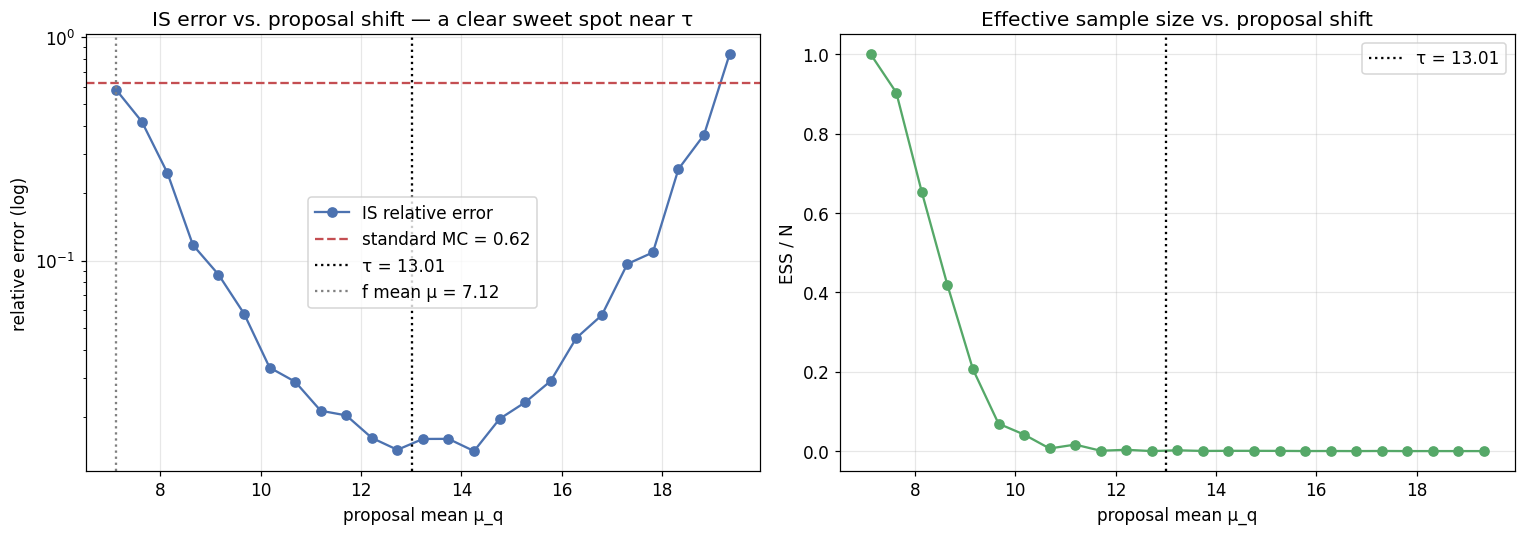

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(mu_grid, rel_err, "o-", color="#4C72B0", label="IS relative error")
axes[0].axhline(mc_relerr, color="#C44E52", ls="--", label=f"standard MC = {mc_relerr:.2f}")
axes[0].axvline(tau, color="k", ls=":", label=f"τ = {tau:.2f}")
axes[0].axvline(mu, color="0.5", ls=":", label=f"f mean μ = {mu:.2f}")
axes[0].set_yscale("log")
axes[0].set_xlabel("proposal mean μ_q"); axes[0].set_ylabel("relative error (log)")
axes[0].set_title("IS error vs. proposal shift — a clear sweet spot near τ"); axes[0].legend()

axes[1].plot(mu_grid, ess_frac, "o-", color="#55A868")
axes[1].axvline(tau, color="k", ls=":", label=f"τ = {tau:.2f}")
axes[1].set_xlabel("proposal mean μ_q"); axes[1].set_ylabel("ESS / N")
axes[1].set_title("Effective sample size vs. proposal shift"); axes[1].legend()
plt.tight_layout()
plt.savefig(RESULTS / "04_proposal_shift_Q4.png", bbox_inches="tight")
plt.show()

**Answer to Q4.** The relative-error curve is **U-shaped**:

* **Shift too small** (\(\mu_q\approx\mu\)): \(q\) barely covers the rare region, almost all draws
  fall below \(\tau\) and contribute 0 — this degenerates back toward standard MC (and can be
  worse because of weight noise).
* **Shift too large** (\(\mu_q\gg\tau\)): now \(q\) over-shoots; the few samples that *do* land in
  \((\tau,\infty)\) carry very large weights \(f/q\), inflating variance and depressing the ESS.
* **Just right** (\(\mu_q\approx\tau\)): error is minimised — orders of magnitude below MC.

So IS is powerful but **not automatic**: a badly matched proposal can perform *worse* than the
crude estimator. The mean-to-threshold rule \(\mu_q\approx\tau\) (with a tail no lighter than
\(f\)) is a robust default.

In [12]:
conv.to_csv(RESULTS / "04_importance_sampling_results.csv")
q2.to_csv(RESULTS / "04_weight_diagnostics_Q2.csv")
print("Saved IS results and weight diagnostics to results/.")

Saved IS results and weight diagnostics to results/.


## 7. Overall conclusions & mapping to the report

| Report section | Where it comes from |
|---|---|
| Data description | Notebook 1 (EDA, summary statistics) |
| Mathematical modelling | Notebook 1 (MLE fits, parameters, chosen \(f\), threshold \(\tau\)) |
| Accept–Reject generation | Notebook 2 (algorithm, acceptance rate vs \(M\), histogram match) |
| Simulation results (variance/error tables) | Notebooks 3 & 4 (CSV tables in `results/`) |
| Histogram real vs generated | `results/02_accept_reject_histograms.png` |
| Error convergence (log–log) | `results/03_mc_convergence.png`, `results/04_importance_sampling.png` |
| IS weight distribution | `results/04_importance_sampling.png`, `results/04_weight_tails_Q2.png` |

**Key findings.**
* The Chloramines exceedance \(P(X>\tau)\approx10^{-4}\) is a genuine rare event.
* Standard Monte-Carlo is unbiased but needs \(N\gtrsim10^5\) to be reliable; at \(N=10^3\) it
  usually returns \(\hat\gamma=0\).
* Importance Sampling with \(q=\mathcal N(\tau,\sigma)\) reaches the same accuracy with **orders of
  magnitude fewer samples** (variance-reduction factors in the thousands).
* IS only works with a sensible proposal: the tail must be no lighter than \(f\) (Q2) and the
  shift must be near \(\tau\) (Q4); otherwise the weights destabilise and IS can lose to MC.

All four analytical questions (Q1 in Notebook 2; Q3 in Notebook 3; Q2 & Q4 here) are answered
with explicit experiments and plots.